In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df= pd.read_excel('/content/retail_sales_dataset.csv.xlsx')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [ ]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
label_encoder=LabelEncoder()
df['Product Category']=label_encoder.fit_transform(df['Product Category'])
df['Gender']=label_encoder.fit_transform(df['Gender'])

In [ ]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,1,34,0,3,50,150
1,2,2023-02-27,CUST002,0,26,1,2,500,1000
2,3,2023-01-13,CUST003,1,50,2,1,30,30
3,4,2023-05-21,CUST004,1,37,1,1,500,500
4,5,2023-05-06,CUST005,1,30,0,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,1,62,1,1,50,50
996,997,2023-11-17,CUST997,1,52,0,3,30,90
997,998,2023-10-29,CUST998,0,23,0,4,25,100
998,999,2023-12-05,CUST999,0,36,2,3,50,150


In [ ]:
#extract year and months as numeric
df['year']=pd.DatetimeIndex(df['Date']).year
df['month']=pd.DatetimeIndex(df['Date']).month
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,year,month
0,1,2023-11-24,CUST001,1,34,0,3,50,150,2023,11
1,2,2023-02-27,CUST002,0,26,1,2,500,1000,2023,2
2,3,2023-01-13,CUST003,1,50,2,1,30,30,2023,1
3,4,2023-05-21,CUST004,1,37,1,1,500,500,2023,5
4,5,2023-05-06,CUST005,1,30,0,2,50,100,2023,5
...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,1,62,1,1,50,50,2023,5
996,997,2023-11-17,CUST997,1,52,0,3,30,90,2023,11
997,998,2023-10-29,CUST998,0,23,0,4,25,100,2023,10
998,999,2023-12-05,CUST999,0,36,2,3,50,150,2023,12


In [ ]:
 df.drop(['Date','Customer ID'],axis=1,inplace=True) # These columns were already dropped

In [ ]:
correlation_matrix=df.corr()
correlation_matrix

,Transaction ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,year,month
Transaction ID,1.000000,0.010387,0.065191,0.032407,-0.026623,-0.060837,-0.075034,-0.010855,0.047538
Gender,0.010387,1.000000,0.002621,0.034423,-0.028023,-0.000961,-0.001001,0.045671,-0.027250
Age,0.065191,0.002621,1.000000,0.039186,-0.023737,-0.038423,-0.060568,0.023269,-0.000640
Product Category,0.032407,0.034423,0.039186,1.000000,-0.010963,-0.003874,-0.005705,-0.001947,0.058968
Quantity,-0.026623,-0.028023,-0.023737,-0.010963,1.000000,0.017501,0.373707,-0.020324,-0.021803
Price per Unit,-0.060837,-0.000961,-0.038423,-0.003874,0.017501,1.000000,0.851925,0.020097,-0.008161
Total Amount,-0.075034,-0.001001,-0.060568,-0.005705,0.373707,0.851925,1.000000,0.024714,-0.005197
year,-0.010855,0.045671,0.023269,-0.001947,-0.020324,0.020097,0.024714,1.000000,-0.071981
month,0.047538,-0.027250,-0.000640,0.058968,-0.021803,-0.008161,-0.005197,-0.071981,1.000000


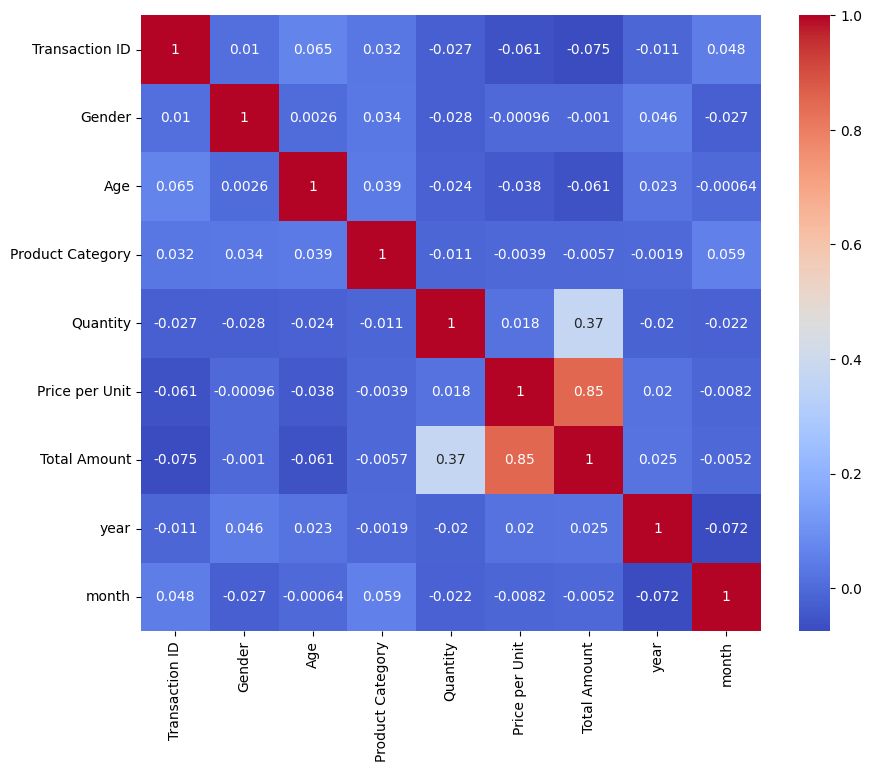

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.show()

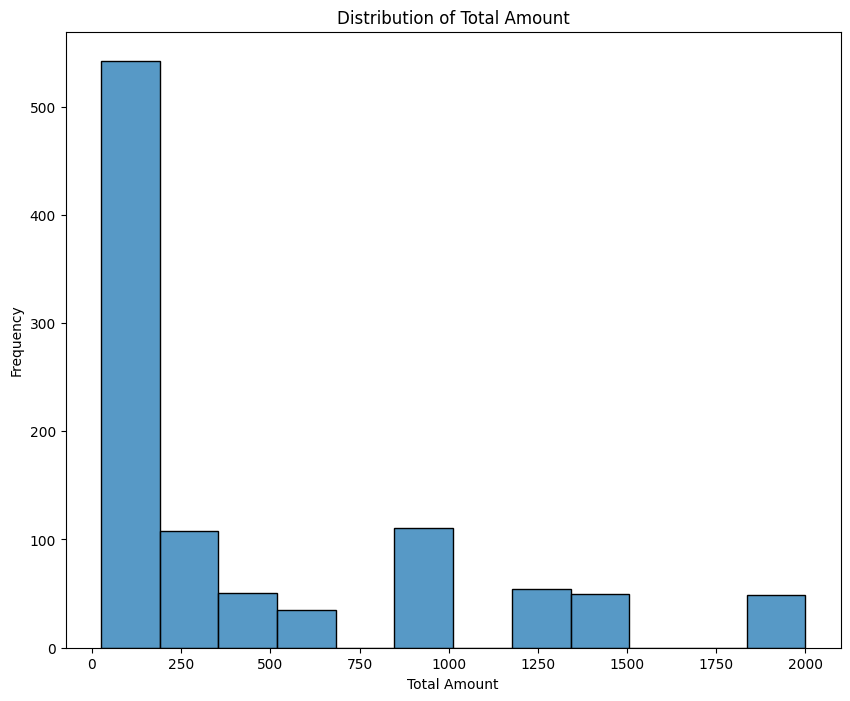

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['Total Amount'])
plt.xlabel('Total Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Total Amount')
plt.show()

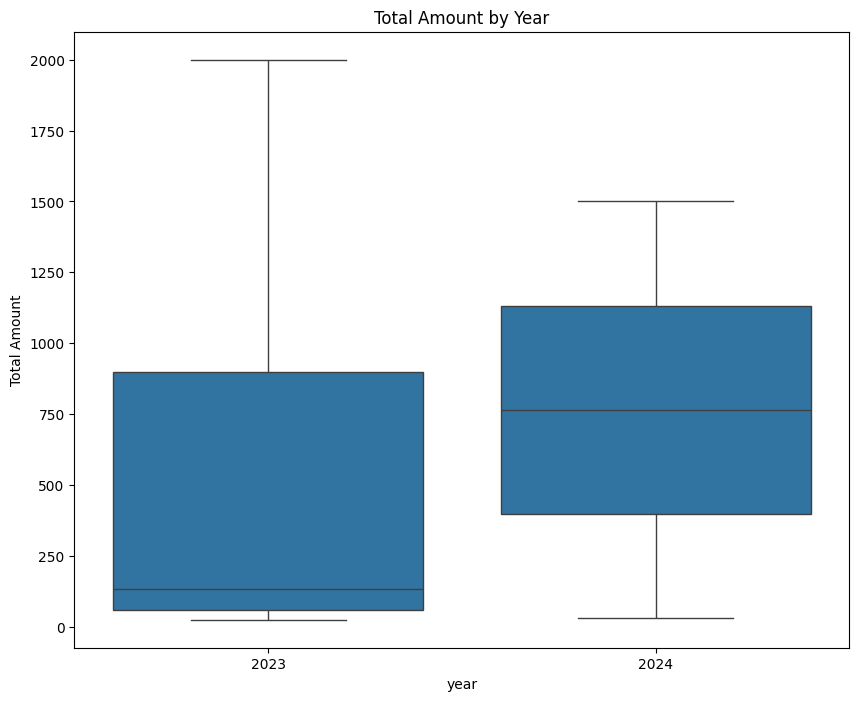

In [ ]:
plt.figure(figsize=(10,8))
sns.boxplot(x='year',y='Total Amount',data=df)
plt.xlabel('year')
plt.ylabel('Total Amount')
plt.title('Total Amount by Year')
plt.show()

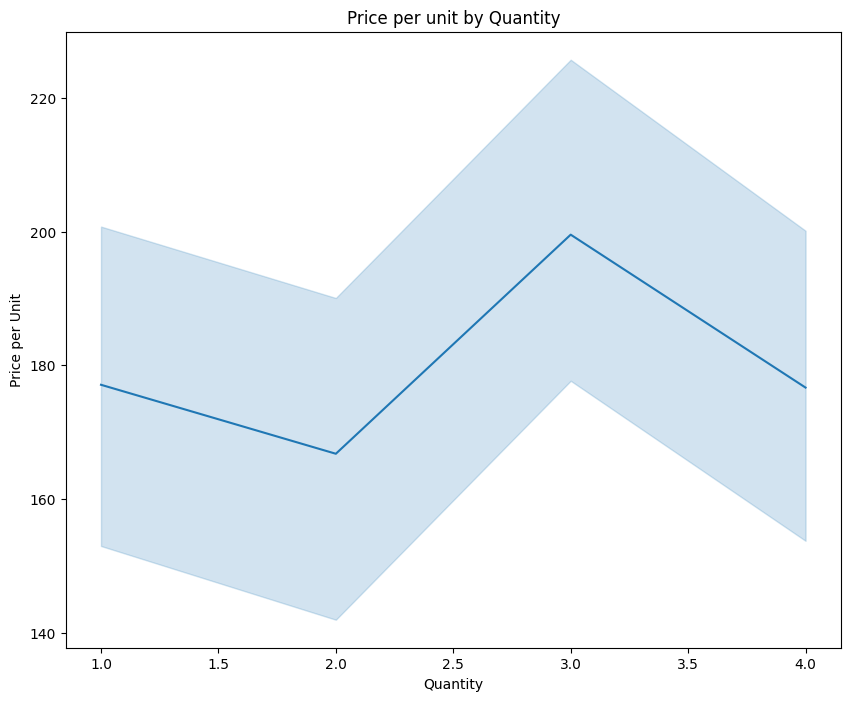

In [ ]:
plt.figure(figsize=(10,8))
sns.lineplot(x='Quantity',y='Price per Unit',data=df)
plt.xlabel('Quantity')
plt.ylabel('Price per Unit')
plt.title('Price per unit by Quantity')
plt.show()

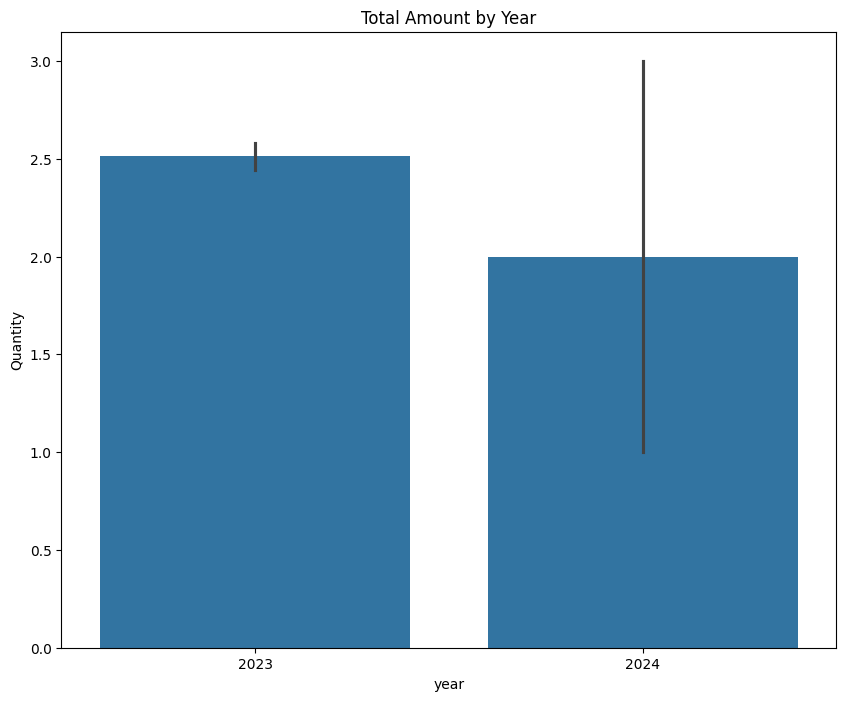

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(x='year',y='Quantity',data=df)
plt.xlabel('year')
plt.ylabel('Quantity')
plt.title('Total Amount by Year')
plt.show()

In [ ]:
df

,Transaction ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,year,month
0,1,1,34,0,3,50,150,2023,11
1,2,0,26,1,2,500,1000,2023,2
2,3,1,50,2,1,30,30,2023,1
3,4,1,37,1,1,500,500,2023,5
4,5,1,30,0,2,50,100,2023,5
...,...,...,...,...,...,...,...,...,...
995,996,1,62,1,1,50,50,2023,5
996,997,1,52,0,3,30,90,2023,11
997,998,0,23,0,4,25,100,2023,10
998,999,0,36,2,3,50,150,2023,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Gender            1000 non-null   int64
 2   Age               1000 non-null   int64
 3   Product Category  1000 non-null   int64
 4   Quantity          1000 non-null   int64
 5   Price per Unit    1000 non-null   int64
 6   Total Amount      1000 non-null   int64
 7   year              1000 non-null   int32
 8   month             1000 non-null   int32
dtypes: int32(2), int64(7)
memory usage: 62.6 KB


**Spilt data into train and test**



In [ ]:
feature_columns=['Age','Quantity','Price per Unit']
target_column=['Total Amount']
X=df[feature_columns]
y=df[target_column]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
linear_model=LinearRegression()
linear_model.fit(x_train,y_train)
print('linearRegression MSE',mean_squared_error(y_test,linear_model.predict(x_test)))

Decision_tree_model=DecisionTreeRegressor()
Decision_tree_model.fit(x_train,y_train)
print('DecisionTreeRegressor MSE',mean_squared_error(y_test,Decision_tree_model.predict(x_test)))

random_forest_model=RandomForestRegressor()
random_forest_model.fit(x_train,y_train)
print('RandomForestRegressor MSE',mean_squared_error(y_test,random_forest_model.predict(x_test)))

linearRegression MSE 41896.21322134358
DecisionTreeRegressor MSE 0.0
RandomForestRegressor MSE 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [ ]:
df=df.drop('Transaction ID', axis=1)

In [ ]:
print("cleaned dataset info:")
print(df.info())

cleaned dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Gender            1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Product Category  1000 non-null   int64
 3   Quantity          1000 non-null   int64
 4   Price per Unit    1000 non-null   int64
 5   Total Amount      1000 non-null   int64
 6   year              1000 non-null   int32
 7   month             1000 non-null   int32
dtypes: int32(2), int64(6)
memory usage: 54.8 KB
None


In [ ]:
#cluster summary analysis
# Perform K-Means clustering
# You need to choose the number of clusters (n_clusters) based on your data and analysis goals.
# For demonstration purposes, let's choose 3 clusters. You might want to use methods like the elbow method to find the optimal number of clusters.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df)

# Display the DataFrame with the new cluster column
display(df)

,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,year,month,cluster
0,1,34,0,3,50,150,2023,11,1
1,0,26,1,2,500,1000,2023,2,0
2,1,50,2,1,30,30,2023,1,1
3,1,37,1,1,500,500,2023,5,0
4,1,30,0,2,50,100,2023,5,1
...,...,...,...,...,...,...,...,...,...
995,1,62,1,1,50,50,2023,5,1
996,1,52,0,3,30,90,2023,11,1
997,0,23,0,4,25,100,2023,10,1
998,0,36,2,3,50,150,2023,12,1


In [ ]:
#step 1 cluster summary
cluster_summary=df.groupby('cluster').mean()
print("cluster summary:\n",cluster_summary)

#categorical per cluster
categorical_summary=df.groupby('cluster')[['Age','Quantity','Price per Unit','Total Amount']].agg(lambda x: x.mode().iloc[0])
print("categorical summary:\n",categorical_summary)

cluster summary:
            Gender        Age  Product Category  Quantity  Price per Unit  \
cluster                                                                    
0        0.474104  41.039841          1.027888  2.474104      379.681275   
1        0.490769  41.861538          1.044615  2.380000       53.984615   
2        0.525253  39.202020          0.989899  3.494949      500.000000   

         Total Amount         year     month  
cluster                                       
0          860.956175  2023.000000  6.509960  
1          102.923077  2023.001538  6.567692  
2         1747.474747  2023.010101  6.525253  
categorical summary:
          Age  Quantity  Price per Unit  Total Amount
cluster                                             
0         43         2             300           900
1         64         1              50            50
2         19         3             500          1500


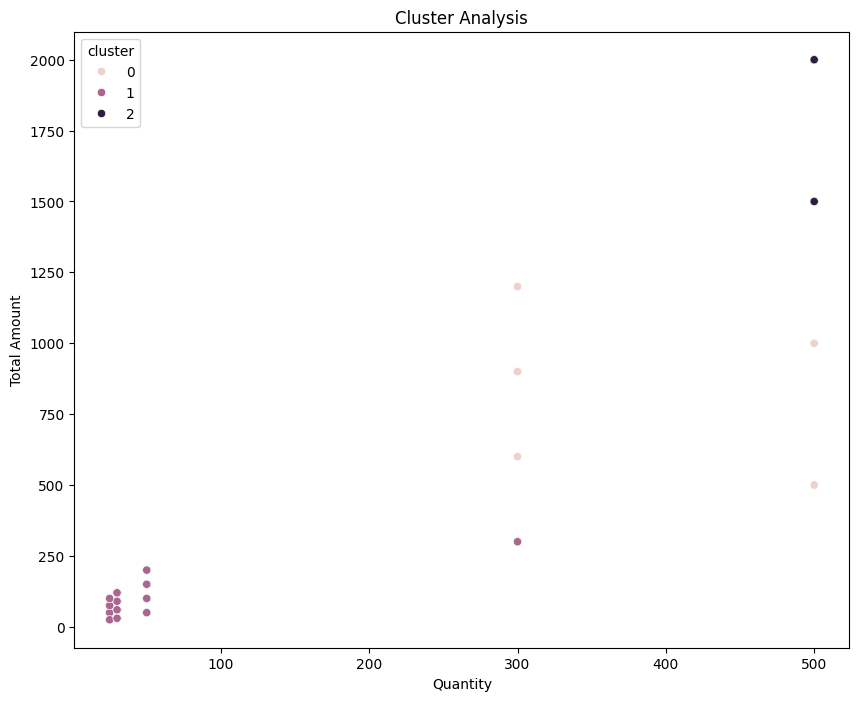

In [ ]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Price per Unit',y='Total Amount',hue='cluster',data=df)
plt.xlabel('Quantity')
plt.ylabel('Total Amount')
plt.title('Cluster Analysis')
plt.show()

In [ ]:
#Model using Random forest classifier

X_cluster=df[feature_columns]
Y_cluster=df['cluster']

#split data into train and test
x_train_cluster,x_test_cluster,y_train_cluster,y_test_cluster=train_test_split(X_cluster,Y_cluster,test_size=0.2,random_state=42)

#Train a random forest Classifier
rf_classifier=RandomForestClassifier(n_estimators=100,random_state=42)
rf_classifier.fit(x_train_cluster,y_train_cluster)

#make a prediction and evalute the model
y_pred_cluster=rf_classifier.predict(x_test_cluster)
print("Random Clasifier Accuracy:",accuracy_score(y_test_cluster,y_pred_cluster))
print("n\Classification Report:",classification_report(y_test_cluster,y_pred_cluster))
print("n\Confusion Matrix:" ,confusion_matrix(y_test_cluster,y_pred_cluster))

Random Clasifier Accuracy: 1.0
n\Classification Report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00       131
           2       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

n\Confusion Matrix: [[ 49   0   0]
 [  0 131   0]
 [  0   0  20]]


<>:16: SyntaxWarning: invalid escape sequence '\C'
<>:17: SyntaxWarning: invalid escape sequence '\C'
<>:16: SyntaxWarning: invalid escape sequence '\C'
<>:17: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipython-input-2769759529.py:16: SyntaxWarning: invalid escape sequence '\C'
  print("n\Classification Report:",classification_report(y_test_cluster,y_pred_cluster))
/tmp/ipython-input-2769759529.py:17: SyntaxWarning: invalid escape sequence '\C'
  print("n\Confusion Matrix:" ,confusion_matrix(y_test_cluster,y_pred_cluster))


In [ ]:
#feature importance
feature_imporatance=pd.Series(rf_classifier.feature_importances_,index=feature_columns).sort_values(ascending=False)
print("Feature Importance:\n",feature_imporatance)

Feature Importance:
 Price per Unit    0.828394
Quantity          0.122889
Age               0.048717
dtype: float64


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy="uniform")  # or "most_frequent"
dummy.fit(x_train, y_train)
y_pred = dummy.predict(x_test)
print("Random Classifier Accuracy:", accuracy_score(y_test_cluster, y_pred_cluster))


Random Classifier Accuracy: 1.0
